In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

In [11]:
fuel_consumption = pd.read_csv('/content/drive/MyDrive/Archivos .csv/FuelConsumption.csv')

In [12]:
# Mostrar la cabecera del Dataframe

fuel_consumption.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230


In [13]:
# Información sobre los tipos de datos
fuel_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              639 non-null    int64  
 1   MAKE              639 non-null    object 
 2   MODEL             639 non-null    object 
 3   VEHICLE CLASS     639 non-null    object 
 4   ENGINE SIZE       639 non-null    float64
 5   CYLINDERS         639 non-null    int64  
 6   TRANSMISSION      639 non-null    object 
 7   FUEL              639 non-null    object 
 8   FUEL CONSUMPTION  639 non-null    float64
 9   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.1+ KB


In [14]:
# Información estadística sobre los datos
fuel_consumption.describe()

,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,639.0,639.000000,639.000000,639.000000,639.000000
mean,2000.0,3.265728,5.805947,14.713615,296.809077
std,0.0,1.231012,1.625588,3.307044,65.504178
min,2000.0,1.000000,3.000000,4.900000,104.000000
25%,2000.0,2.200000,4.000000,12.500000,253.000000
50%,2000.0,3.000000,6.000000,14.400000,288.000000
75%,2000.0,4.300000,6.000000,16.600000,343.000000
max,2000.0,8.000000,12.000000,30.200000,582.000000


In [23]:
# Contar los valores distintos de un campo categorico
fuel_consumption['CYLINDERS'].value_counts()

,count
CYLINDERS,
6,263
4,209
8,136
5,19
12,7
3,3
10,2


In [37]:
# Selección de filas por comparación
car_before_2001 = fuel_consumption[fuel_consumption['ENGINE SIZE'] < 3.2]
car_before_2001.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332 entries, 0 to 638
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Year              332 non-null    int64   
 1   MAKE              332 non-null    object  
 2   MODEL             332 non-null    object  
 3   VEHICLE CLASS     332 non-null    object  
 4   ENGINE SIZE       332 non-null    float64 
 5   CYLINDERS         332 non-null    int64   
 6   TRANSMISSION      332 non-null    object  
 7   FUEL              332 non-null    object  
 8   FUEL CONSUMPTION  332 non-null    float64 
 9   COEMISSIONS       332 non-null    int64   
 10  income_cat        332 non-null    category
dtypes: category(1), float64(2), int64(3), object(5)
memory usage: 29.0+ KB


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'ENGINE SIZE'}>],
       [<Axes: title={'center': 'CYLINDERS'}>,
        <Axes: title={'center': 'FUEL CONSUMPTION'}>],
       [<Axes: title={'center': 'COEMISSIONS '}>, <Axes: >]], dtype=object)

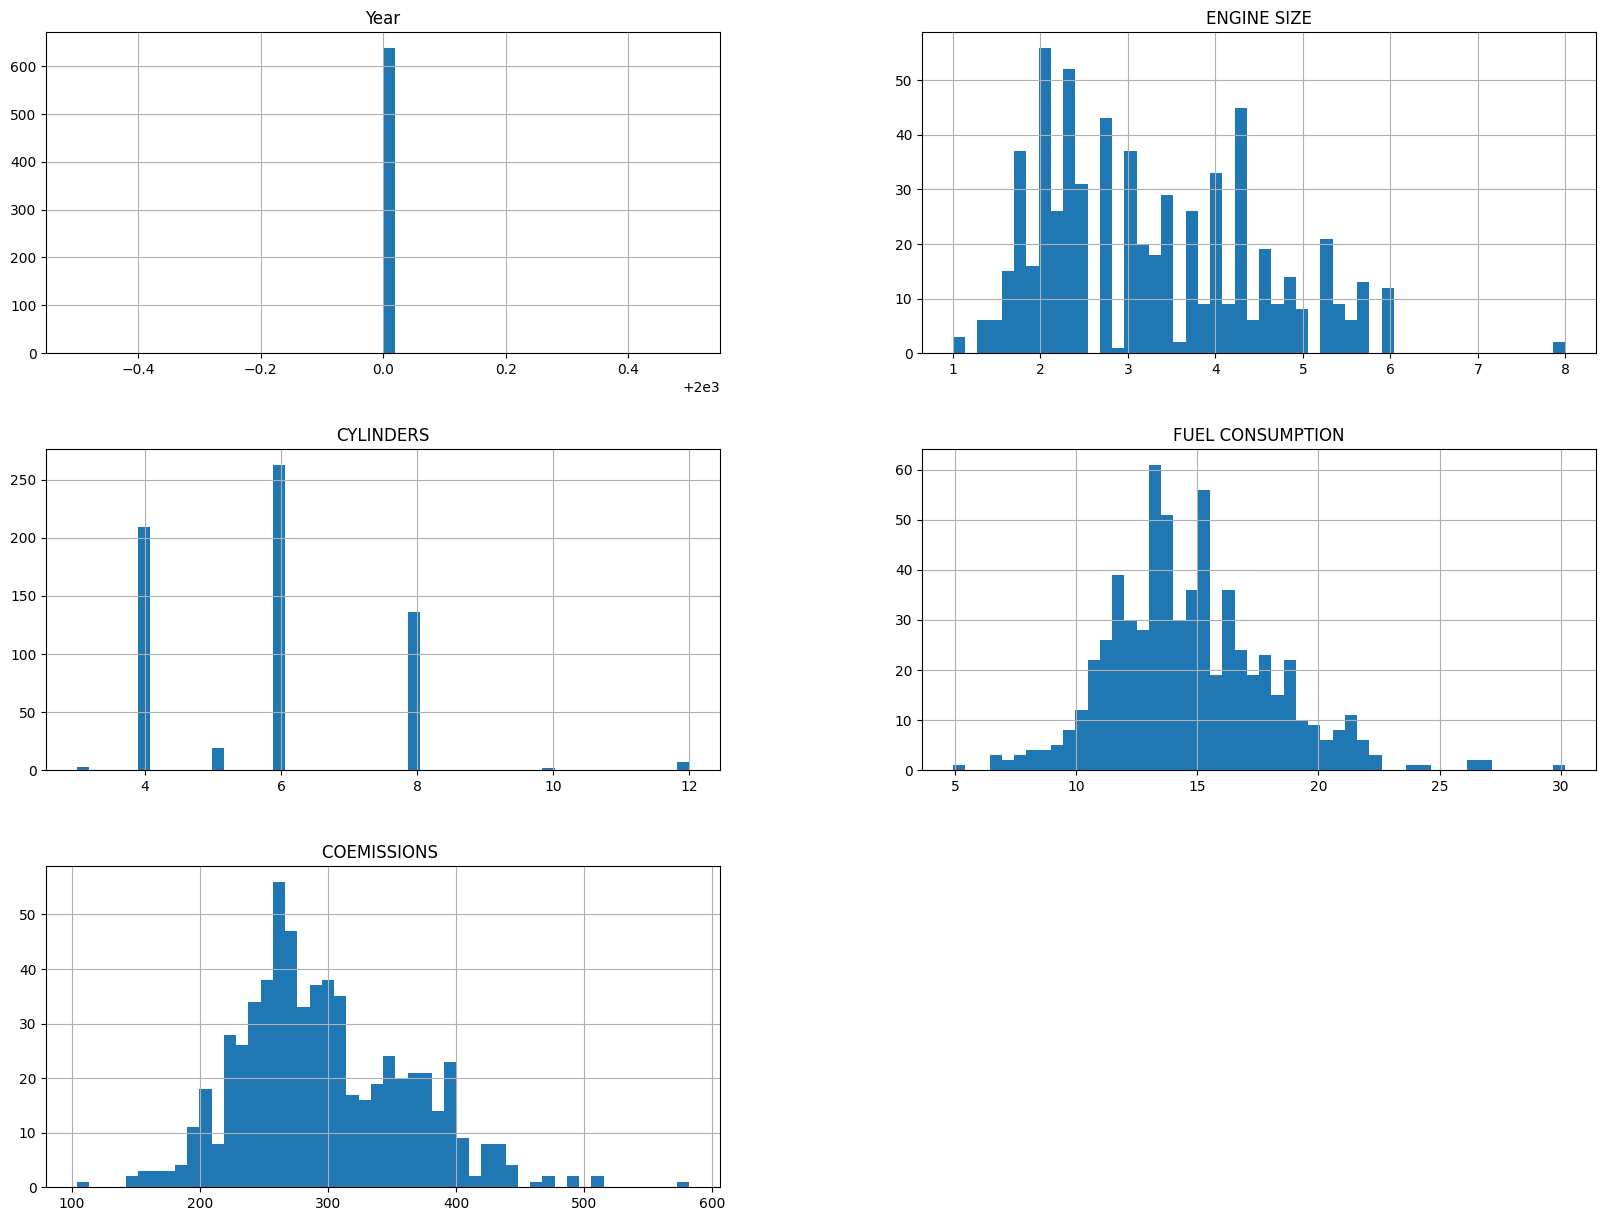

In [38]:
#Representar el histograma de FuelConsumption
fuel_consumption.hist(bins=50,figsize=(20,15))

In [51]:
fuel_consumption["income_cat"] = pd.cut(fuel_consumption["ENGINE SIZE"],
                                bins = [0., 1.6, 3.0, np.inf],
                                labels = [1, 2, 3])

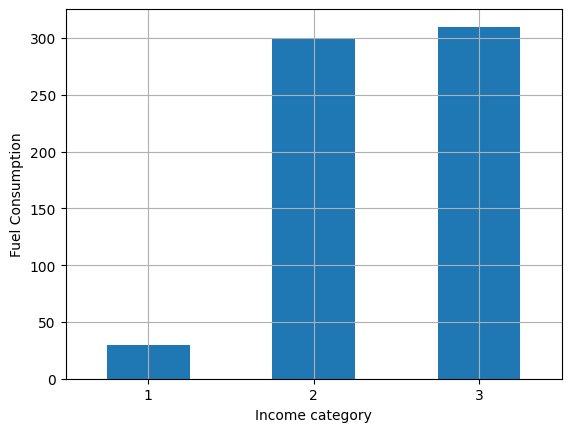

In [52]:
fuel_consumption["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Fuel Consumption")
plt.show()

In [36]:
fuel_consumption["income_cat"].value_counts().sort_index()

,count
income_cat,
1,30
2,299
3,310


In [41]:
strat_train_set, strat_test_set = train_test_split(
    fuel_consumption, test_size=0.2, stratify=fuel_consumption["income_cat"], random_state=42)
print(strat_train_set['income_cat'].value_counts().sort_index())
print(strat_test_set['income_cat'].value_counts().sort_index())

income_cat
1     24
2    239
3    248
Name: count, dtype: int64
income_cat
1     6
2    60
3    62
Name: count, dtype: int64


array([[<Axes: xlabel='CYLINDERS', ylabel='CYLINDERS'>,
        <Axes: xlabel='ENGINE SIZE', ylabel='CYLINDERS'>,
        <Axes: xlabel='FUEL CONSUMPTION', ylabel='CYLINDERS'>,
        <Axes: xlabel='COEMISSIONS ', ylabel='CYLINDERS'>],
       [<Axes: xlabel='CYLINDERS', ylabel='ENGINE SIZE'>,
        <Axes: xlabel='ENGINE SIZE', ylabel='ENGINE SIZE'>,
        <Axes: xlabel='FUEL CONSUMPTION', ylabel='ENGINE SIZE'>,
        <Axes: xlabel='COEMISSIONS ', ylabel='ENGINE SIZE'>],
       [<Axes: xlabel='CYLINDERS', ylabel='FUEL CONSUMPTION'>,
        <Axes: xlabel='ENGINE SIZE', ylabel='FUEL CONSUMPTION'>,
        <Axes: xlabel='FUEL CONSUMPTION', ylabel='FUEL CONSUMPTION'>,
        <Axes: xlabel='COEMISSIONS ', ylabel='FUEL CONSUMPTION'>],
       [<Axes: xlabel='CYLINDERS', ylabel='COEMISSIONS '>,
        <Axes: xlabel='ENGINE SIZE', ylabel='COEMISSIONS '>,
        <Axes: xlabel='FUEL CONSUMPTION', ylabel='COEMISSIONS '>,
        <Axes: xlabel='COEMISSIONS ', ylabel='COEMISSIONS '>]],
   

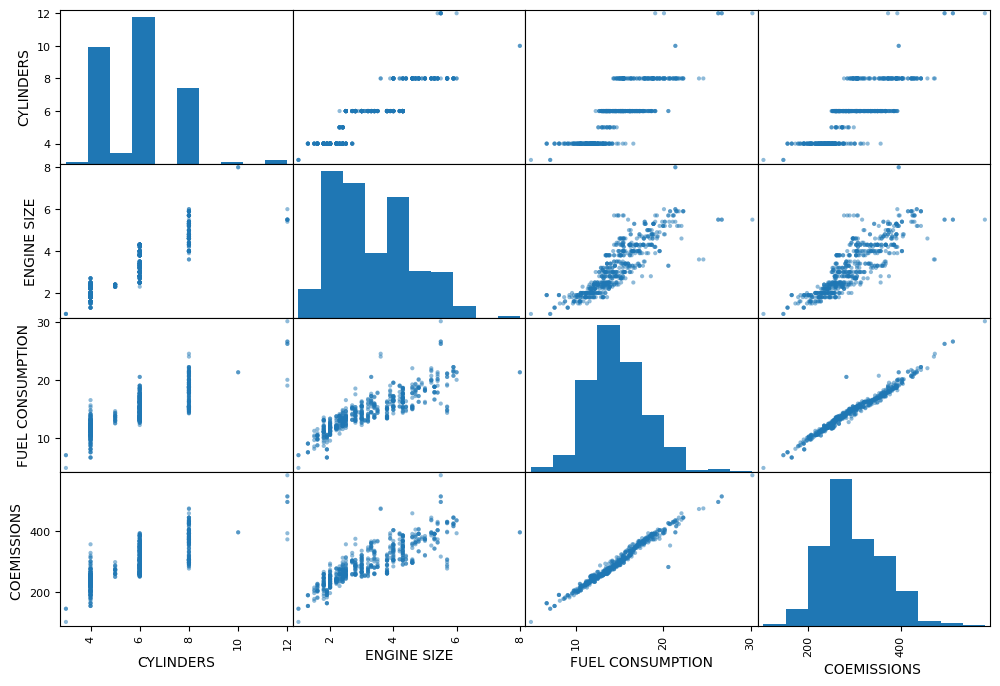

In [44]:
attributes = ["CYLINDERS", "ENGINE SIZE", "FUEL CONSUMPTION",
              "COEMISSIONS "]
scatter_matrix(fuel_consumption[attributes], figsize=(12, 8))

In [53]:
from sklearn.preprocessing import OneHotEncoder
fuel_num = fuel_consumption.drop("CYLINDERS", axis=1)
fuel_cat = fuel_consumption[["CYLINDERS"]]
cat_encoder = OneHotEncoder()
fuel_cat_1hot = cat_encoder.fit_transform(fuel_cat)

fuel_cat2=fuel_cat_1hot.toarray()
housesCats=pd.DataFrame(fuel_cat2,columns=cat_encoder.categories_[0])


houses_after_onehot=pd.concat([fuel_num,housesCats],axis=1)
houses_after_onehot.head()

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS,income_cat,3,4,5,6,8,10,12
0,2000,ACURA,1.6EL,COMPACT,1.6,A4,X,10.5,216,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2000,ACURA,1.6EL,COMPACT,1.6,M5,X,9.8,205,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2000,ACURA,3.2TL,MID-SIZE,3.2,AS5,Z,13.7,265,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2000,ACURA,3.5RL,MID-SIZE,3.5,A4,Z,15.0,301,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,A4,X,11.4,230,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
